# P648: Alzheimer's Disease EDA & Classification

# EDA

## 1. Data Loading & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("alzheimers_disease_data.csv")
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


## 2. Dataset Overview

In [3]:
df.dtypes

PatientID                      int64
Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems             int64
A

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [5]:
df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

In [6]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates == 0:
    print("✓ No duplicates found - Data is clean!")

Duplicate rows: 0
✓ No duplicates found - Data is clean!


In [7]:
# Detect outliers for key features
key_features = ['Age', 'BMI', 'MMSE', 'ADL']

print("Outliers Detection (IQR Method):")
for feature in key_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)]
    print(f"{feature}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

Outliers Detection (IQR Method):
Age: 0 outliers (0.0%)
BMI: 0 outliers (0.0%)
MMSE: 0 outliers (0.0%)
ADL: 0 outliers (0.0%)


## 3. Statistical Summary

In [8]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Target Variable Distribution

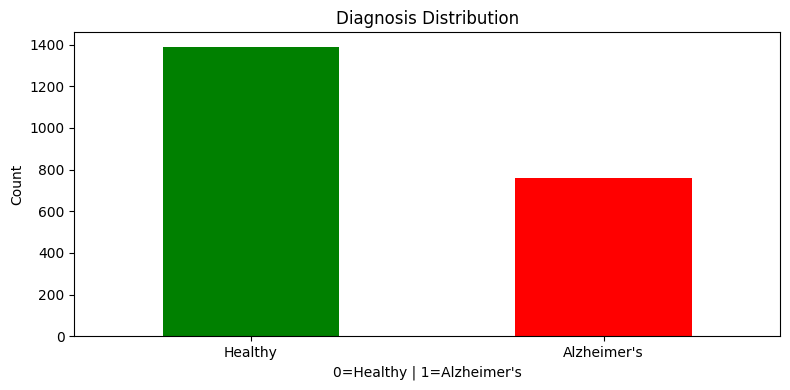

In [9]:
# Target Variable Distribution

# Healthy: 1389 (64.6%)
# Alzheimer's: 760 (35.4%)


df['Diagnosis'].value_counts()

plt.figure(figsize=(8, 4))
df['Diagnosis'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Diagnosis Distribution')
plt.xlabel('0=Healthy | 1=Alzheimer\'s')
plt.ylabel('Count')
plt.xticks([0, 1], ['Healthy', "Alzheimer's"], rotation=0)
plt.tight_layout()
plt.show()

## 5. Key Features Distribution

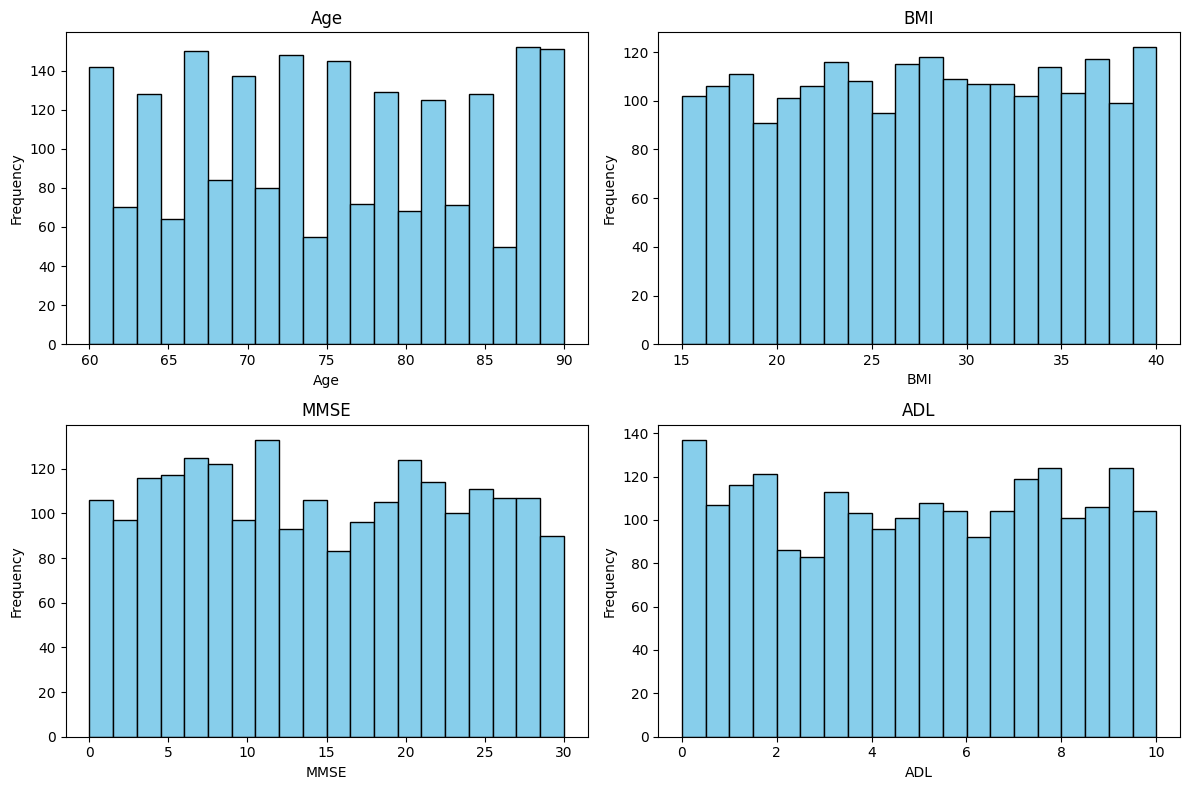

In [10]:
# Key Features Distribution

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df[feature], bins=20, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'{feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Feature Relationships with Diagnosis

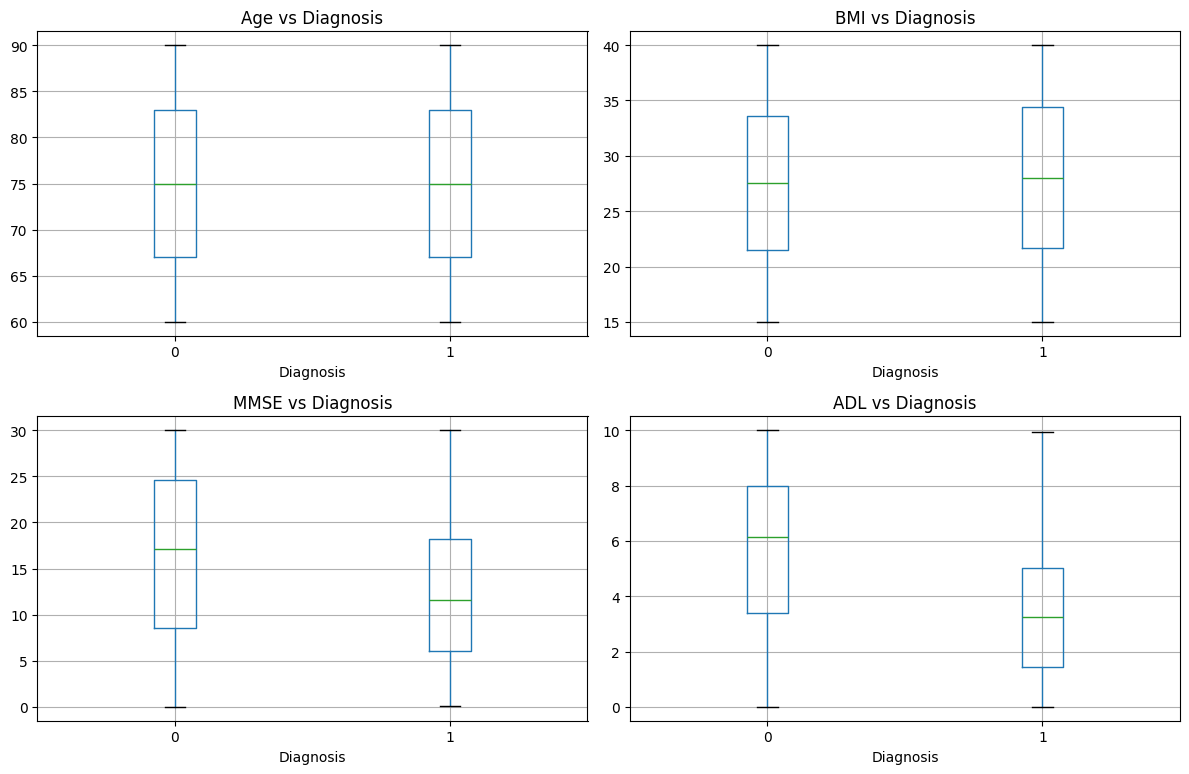

In [11]:
# Features vs Diagnosis Comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    df.boxplot(column=feature, by='Diagnosis', ax=axes[idx])
    axes[idx].set_title(f'{feature} vs Diagnosis')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

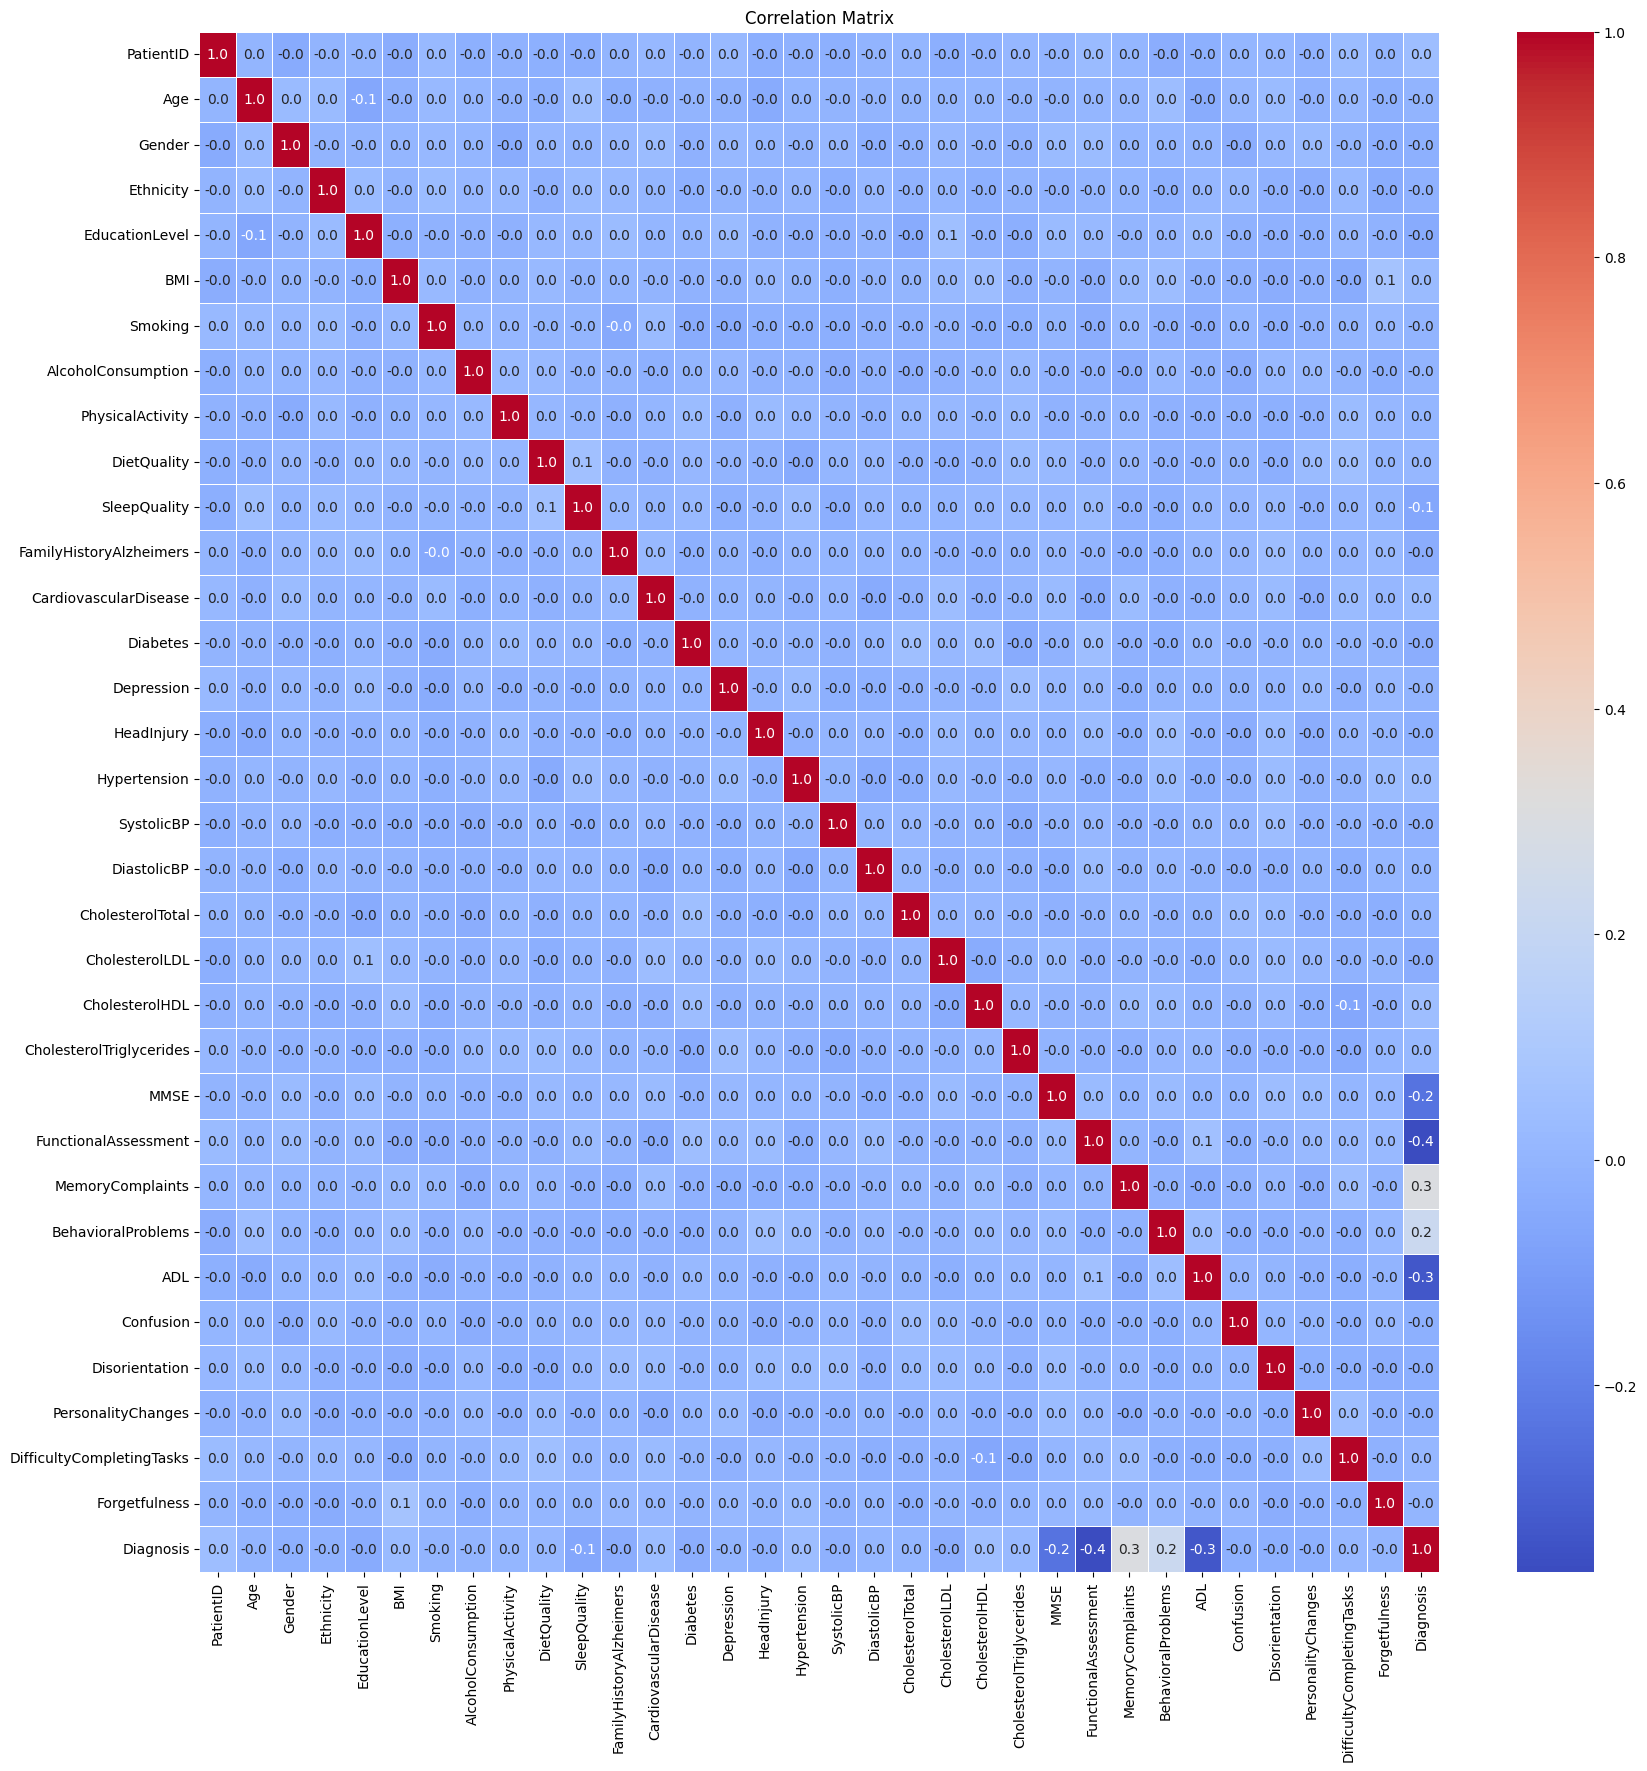

In [12]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## 8. Correlation with Diagnosis


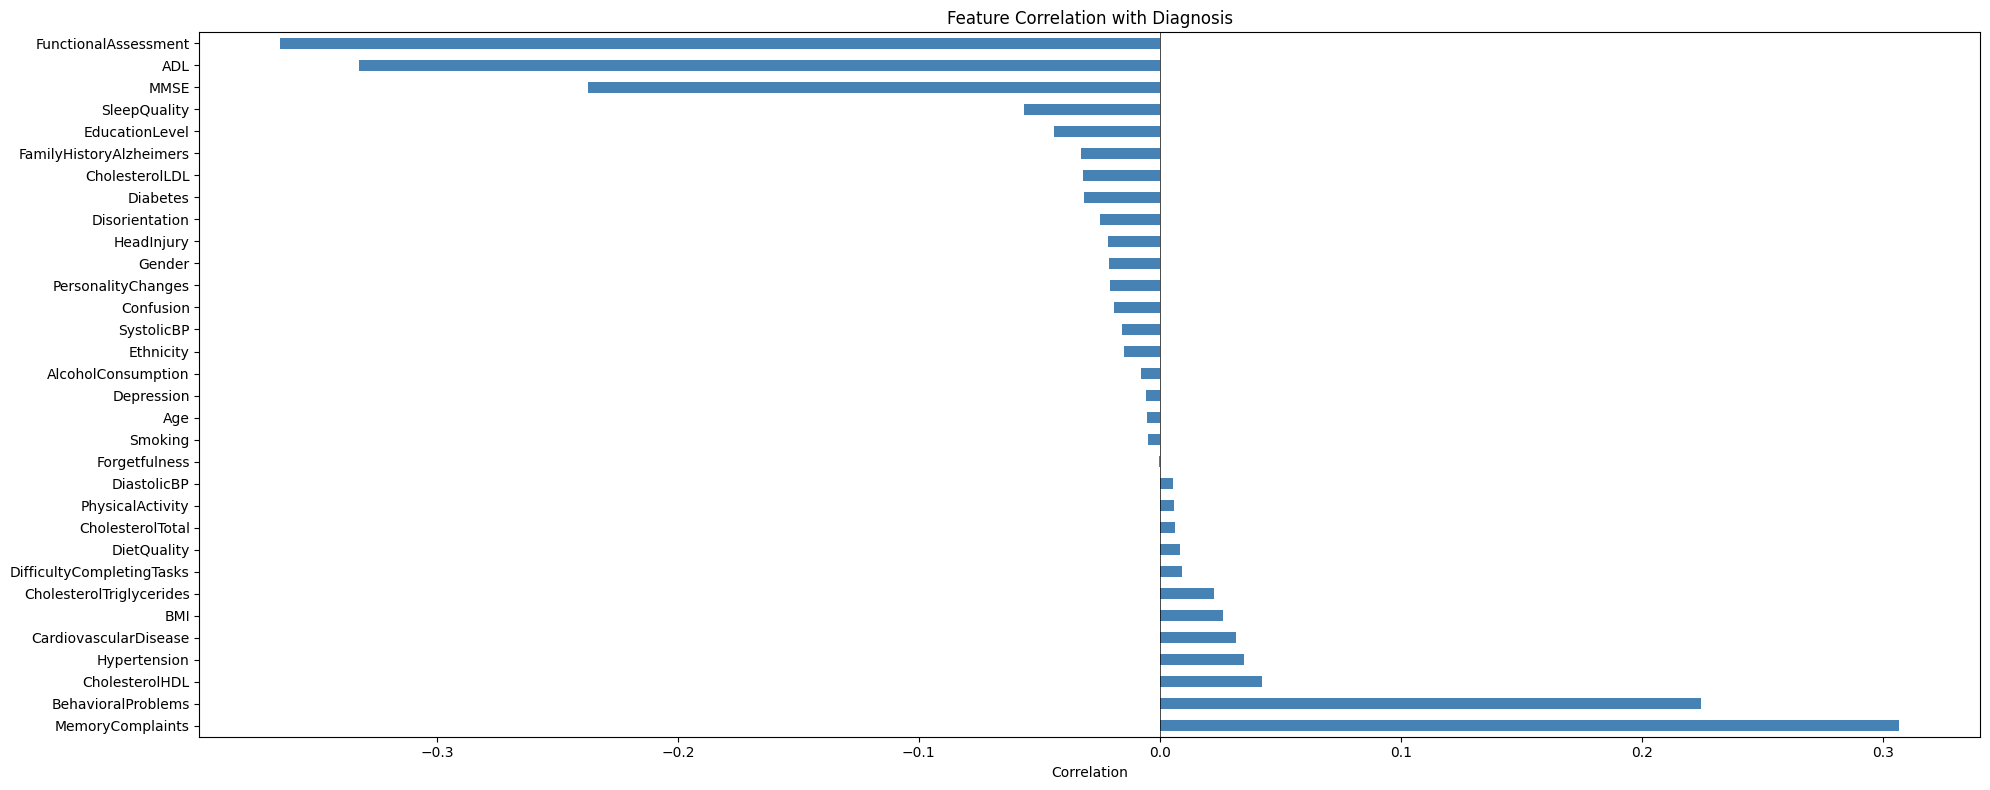

In [13]:
corr_with_diagnosis = df.corr(numeric_only=True)['Diagnosis'].sort_values(ascending=False)
corr_with_diagnosis.drop(['Diagnosis','PatientID'] ,inplace=True)

plt.figure(figsize=(20, 8))
corr_with_diagnosis[corr_with_diagnosis.index != 'Diagnosis'].plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Diagnosis')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

Top 15 Most Important Features (by correlation):
FunctionalAssessment       0.364898
ADL                        0.332346
MemoryComplaints           0.306742
MMSE                       0.237126
BehavioralProblems         0.224350
SleepQuality               0.056548
EducationLevel             0.043966
CholesterolHDL             0.042584
Hypertension               0.035080
FamilyHistoryAlzheimers    0.032900
CholesterolLDL             0.031976
Diabetes                   0.031508
CardiovascularDisease      0.031490
BMI                        0.026343
Disorientation             0.024648
Name: Diagnosis, dtype: float64


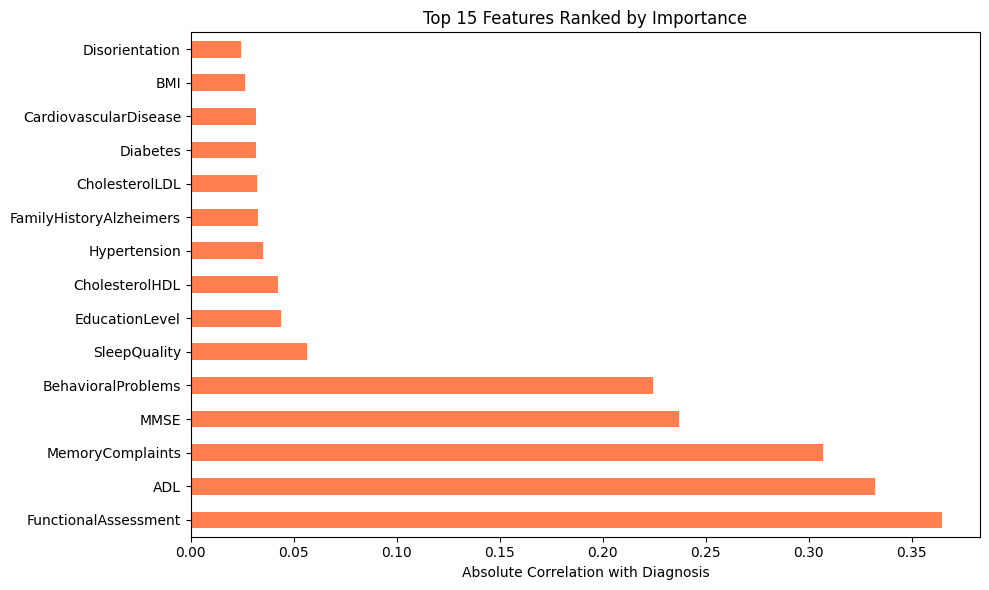

In [14]:
# Rank features by absolute correlation with diagnosis
feature_importance = corr_with_diagnosis.abs().sort_values(ascending=False)
feature_importance = feature_importance[feature_importance.index != 'Diagnosis']

print("Top 15 Most Important Features (by correlation):")
print(feature_importance.head(15))

# Visualize
plt.figure(figsize=(10, 6))
feature_importance.head(15).plot(kind='barh', color='coral')
plt.title('Top 15 Features Ranked by Importance')
plt.xlabel('Absolute Correlation with Diagnosis')
plt.tight_layout()
plt.show()

---

# Data Preprocessing & Preparation

## 9. Feature & Target Preparation

In [15]:
# Prepare features and target
X = df.drop(['PatientID', 'Diagnosis', 'DoctorInCharge'], axis=1)
y = df['Diagnosis']

## 10. Train-Test Split

In [16]:
# Split data into 80% train, 20% test with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 11. EDA Summary & Key Insights


1. DATASET OVERVIEW:
   - Total samples: 2149
   - Total features: 35
   - Missing values: 0
   - Duplicate rows: 0

2. CLASS IMBALANCE:
   - Healthy: 1389 (64.6%)
   - Alzheimer's: 760 (35.4%)

3. TOP DISCRIMINATIVE FEATURES:
   1. FunctionalAssessment: 0.3649
   2. ADL: 0.3323
   3. MemoryComplaints: 0.3067
   4. MMSE: 0.2371
   5. BehavioralProblems: 0.2244

4. STATISTICAL SIGNIFICANCE:
...
   - Apply SMOTE to balance classes before training
   - Scale features standardization before modeling
   - Use top features for better model performance

## 12 Model Building

In [17]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [18]:
def prediction(model):
  model.fit(X_train_scaled,y_train_balanced)
  ypred = model.predict(X_test_scaled)
  print('Train Accuracy: ',model.score(X_train_scaled,y_train_balanced))
  print('Test Accuracy: ',model.score(X_test_scaled,y_test))
  print(classification_report(y_test,ypred))
  print("\nConfusion Matrix:\n", confusion_matrix(y_test, ypred))

In [19]:
prediction(XGBClassifier())

NameError: name 'X_train_scaled' is not defined

In [20]:
prediction(model = LGBMClassifier(
    objective="binary",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=12,
    min_child_samples=40,
    reg_alpha=2,
    reg_lambda=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
))

  # 'num_leaves': [12, 22, 32, 42],
  #  'max_depth': [-1, 4, 8],
  #  'learning_rate': [0.01, 0.03, 0.05, 0.1],
  #  'n_estimators': [100, 200, 300, 400],
  #  'min_child_samples': [10, 20, 30, 40, 50],
  #  'subsample': [0.7, 0.8, 1.0],
  #  'colsample_bytree': [0.7, 0.8, 1.0],
  #  'reg_alpha': [0, 0.1, 1, 2],
  #  'reg_lambda': [0, 0.1, 1, 2, 3]

NameError: name 'X_train_scaled' is not defined

In [21]:
param_grid = {
  'num_leaves': [12, 22, 32, 42],
   'max_depth': [-1, 4, 8],
   'learning_rate': [0.01, 0.03, 0.05, 0.1],
   'n_estimators': [100, 200, 300, 400],
   'min_child_samples': [10, 20, 30, 40, 50],
   'subsample': [0.7, 0.8, 1.0],
   'colsample_bytree': [0.7, 0.8, 1.0],
   'reg_alpha': [0, 0.1, 1, 2],
   'reg_lambda': [0, 0.1, 1, 2, 3]
}

In [22]:
grid = GridSearchCV(
    estimator=LGBMClassifier(),
    param_grid=param_grid,
    scoring='accuracy',   # you may use 'f1' or 'roc_auc'
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [23]:
grid.fit(X_train_scaled,y_train_balanced)

NameError: name 'X_train_scaled' is not defined

In [24]:
# @title
prediction(LGBMClassifier(
    objective="binary",
    n_estimators=400, # Number of boosting trees
    learning_rate=0.03,
    max_depth=4, # Maximum depth of each tree.
    num_leaves=12, # Maximum leaves per tree.
    min_child_samples=40,
    reg_alpha=2,  #L1 Regularization
    reg_lambda=3, #L2 Regularization
    subsample=0.8, # Row sampling, Each tree sees only 80% of training data
    colsample_bytree=0.8, # Feature sampling, Each tree sees only 80% of features
    random_state=42))

NameError: name 'X_train_scaled' is not defined

In [25]:
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import LinearSVC

In [39]:
pipe = Pipeline([
    ('feature_selection', SelectFromModel(LinearSVC(penalty="l1", dual=False))),
    ('scaler', StandardScaler()),
    ('model', LGBMClassifier(
    objective="binary",
    n_estimators=400, # Number of boosting trees
    learning_rate=0.03,
    max_depth=4, # Maximum depth of each tree.
    num_leaves=12, # Maximum leaves per tree.
    min_child_samples=40,
    reg_alpha=2,  #L1 Regularization
    reg_lambda=3, #L2 Regularization
    subsample=0.8, # Row sampling, Each tree sees only 80% of training data
    colsample_bytree=0.8, # Feature sampling, Each tree sees only 80% of features
    random_state=42))
])

pipe.fit(X_train, y_train)
ypred=pipe.predict(X_test)
print('Train Accuracy: ',pipe.score(X_train, y_train))
print('Test Accuracy: ',pipe.score(X_test, y_test))
print(classification_report(y_test,ypred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, ypred))
selector = pipe.named_steps['feature_selection']

# Get boolean mask of selected features
selected_mask = selector.get_support()

# Get selected feature names
selected_features = X_train.columns[selected_mask].tolist()

print(f"Number of features selected: {len(selected_features)}")
print(f"Selected features: {selected_features}")
import pandas as pd

# Get the underlying LinearSVC coefficients (absolute value = importance)
lsvc = selector.estimator_
coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': abs(lsvc.coef_[0]),
    'selected': selected_mask
}).sort_values('coefficient', ascending=False)

print(coefficients)

[LightGBM] [Info] Number of positive: 608, number of negative: 1111
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000658 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3299
[LightGBM] [Info] Number of data points in the train set: 1719, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.353694 -> initscore=-0.602841
[LightGBM] [Info] Start training from score -0.602841
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

In [29]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}


In [32]:
pipe = Pipeline([
    ('feature_selection', SelectFromModel(LinearSVC(penalty="l1", dual=False))),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train, y_train)
ypred=pipe.predict(X_test)
print('Train Accuracy: ',pipe.score(X_train, y_train))
print('Test Accuracy: ',pipe.score(X_test, y_test))
print(classification_report(y_test,ypred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, ypred))

Train Accuracy:  0.8510762070971495
Test Accuracy:  0.8162790697674419
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       278
           1       0.74      0.74      0.74       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430


Confusion Matrix:
 [[239  39]
 [ 40 112]]


In [34]:
pipe = Pipeline([
    ('feature_selection', SelectFromModel(LinearSVC(penalty="l1", dual=False))),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe.fit(X_train, y_train)
ypred=pipe.predict(X_test)
print('Train Accuracy: ',pipe.score(X_train, y_train))
print('Test Accuracy: ',pipe.score(X_test, y_test))
print(classification_report(y_test,ypred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, ypred))

Train Accuracy:  1.0
Test Accuracy:  0.9372093023255814
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       278
           1       0.94      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.94      0.94       430


Confusion Matrix:
 [[269   9]
 [ 18 134]]


In [35]:
pipe = Pipeline([
    ('feature_selection', SelectFromModel(LinearSVC(penalty="l1", dual=False))),
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', probability=True, random_state=42))
])

pipe.fit(X_train, y_train)
ypred=pipe.predict(X_test)
print('Train Accuracy: ',pipe.score(X_train, y_train))
print('Test Accuracy: ',pipe.score(X_test, y_test))
print(classification_report(y_test,ypred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, ypred))

Train Accuracy:  0.9412449098312973
Test Accuracy:  0.8348837209302326
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       278
           1       0.79      0.72      0.76       152

    accuracy                           0.83       430
   macro avg       0.82      0.81      0.82       430
weighted avg       0.83      0.83      0.83       430


Confusion Matrix:
 [[249  29]
 [ 42 110]]


In [37]:
pipe = Pipeline([
    ('feature_selection', SelectFromModel(LinearSVC(penalty="l1", dual=False))),
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(random_state=42))
])

pipe.fit(X_train, y_train)
ypred=pipe.predict(X_test)
print('Train Accuracy: ',pipe.score(X_train, y_train))
print('Test Accuracy: ',pipe.score(X_test, y_test))
print(classification_report(y_test,ypred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, ypred))
selector = pipe.named_steps['feature_selection']

# Get boolean mask of selected features
selected_mask = selector.get_support()

# Get selected feature names
selected_features = X_train.columns[selected_mask].tolist()

print(f"Number of features selected: {len(selected_features)}")
print(f"Selected features: {selected_features}")

Train Accuracy:  0.9668411867364747
Test Accuracy:  0.9488372093023256
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       278
           1       0.93      0.92      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430


Confusion Matrix:
 [[268  10]
 [ 12 140]]
Number of features selected: 32
Selected features: ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCo

In [43]:
from sklearn.feature_selection import SelectKBest, f_classif

In [61]:
pipe = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_classif, k=6)),
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(
    # --- Core ---
    n_estimators=100,        # Number of boosting stages (trees)
    learning_rate=0.1,       # Shrinks contribution of each tree
    random_state=42,

    # --- Regularization ---
    max_depth=3,             # Depth of each tree (main regularizer)
    min_samples_split=2,     # Min samples to split an internal node
    min_samples_leaf=1,      # Min samples required at a leaf node
    max_features='sqrt',     # Features considered per split ('sqrt', 'log2', float)
    subsample=0.8,           # Fraction of samples per tree (< 1.0 = stochastic GB)
    max_leaf_nodes=None,     # Limit number of leaves per tree

    # --- Loss ---
    loss='log_loss',         # 'log_loss' or 'exponential' (AdaBoost-like)

    # --- Early Stopping ---
    n_iter_no_change=10,     # Stop if no improvement for N rounds
    validation_fraction=0.1, # Data fraction used for early stopping
    tol=1e-4,                # Tolerance for early stopping

    # --- Speed ---
    warm_start=False,        # Reuse previous fit (add more trees incrementally)
))
])

pipe.fit(X_train, y_train)
ypred=pipe.predict(X_test)
print('Train Accuracy: ',pipe.score(X_train, y_train))
print('Test Accuracy: ',pipe.score(X_test, y_test))
print(classification_report(y_test,ypred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, ypred))
selector = pipe.named_steps['feature_selection']

# Get boolean mask of selected features
selected_mask = selector.get_support()

# Get selected feature names
selected_features = X_train.columns[selected_mask].tolist()

print(f"Number of features selected: {len(selected_features)}")
print(f"Selected features: {selected_features}")
selector = pipe.named_steps['feature_selection']

# Get feature scores and selected mask
feature_scores = pd.DataFrame({
    'feature': X_train.columns,
    'score': selector.scores_,
    'selected': selector.get_support()
}).sort_values('score', ascending=False)

print(feature_scores)

# Get only selected feature names
selected_features = X_train.columns[selector.get_support()].tolist()
print("\nSelected features:", selected_features)

Train Accuracy:  0.9598603839441536
Test Accuracy:  0.9534883720930233
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       278
           1       0.94      0.93      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.95      0.95       430
weighted avg       0.95      0.95      0.95       430


Confusion Matrix:
 [[269   9]
 [ 11 141]]
Number of features selected: 6
Selected features: ['SleepQuality', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL']
                      feature       score  selected
23       FunctionalAssessment  257.318763      True
26                        ADL  219.327424      True
24           MemoryComplaints  199.616266      True
22                       MMSE  101.512032      True
25         BehavioralProblems   79.965086      True
9                SleepQuality    5.240384      True
20             CholesterolHDL    4.667156     F